In [118]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib import colormaps
from matplotlib.colors import LogNorm
import os
import scipy.stats as stats
import adjustText
from statsmodels.stats.multicomp import pairwise_tukeyhsd, MultiComparison
from string import ascii_lowercase
import random
#from helper_functions import *
import polars as pl

In [119]:
sb.set_context("paper")
sb.set_theme(font_scale=1.2)

 ## Functions

In [120]:
# Simplified alternative: use Tukey's summary directly
def tukey_to_letter_dict(tukey_result, GROUP_COLORS):
    groups = GROUP_COLORS.keys()
    letter_map = {g: set([g]) for g in groups}
    reject_df = pd.DataFrame(tukey_result._results_table.data[1:], columns=tukey_result._results_table.data[0])

    # Initialize
    letters = {}
    current_letter = 0
    group_sets = []

    for g in groups:
        added = False
        for s in group_sets:
            if all(
                not (
                    ((row['group1'] == g and row['group2'] in s) or 
                     (row['group2'] == g and row['group1'] in s)) 
                    and row['reject'])
                for _, row in reject_df.iterrows()
            ):
                s.add(g)
                added = True
                break
        if not added:
            group_sets.append(set([g]))

    # Assign letters
    for idx, s in enumerate(group_sets):
        for g in s:
            letters.setdefault(g, '')
            letters[g] += ascii_lowercase[idx]
    return letters


def agg_mode_sum(series):
    if pd.api.types.is_numeric_dtype(series):
        return series.sum()
    else:
        return series.mode().iat[0] if not series.mode().empty else None
def count_modules(data, name, id='BinID'):
    path_sum = data.groupby(id)[name].sum()
    print(path_sum)
    temp = {}
    for k,v in path_sum.items():
        temp[k]  = {i:v.count(i) for i in v}    
    return temp


def count_pathway(data, name, group='BinID'):
    
    return data.groupby(group)[name].value_counts().to_frame().unstack().fillna(0).droplevel(0, axis=1)



def group_genus(data, tax_table):
    data['Genus'] = tax_table['Genus']
    return data.groupby('Genus').mean()


def replace_rare_cat(df, max_colors=20, cat_name=None):
    rare_cats = (df[cat_name].value_counts().sort_values(ascending=False)[max_colors:]).index
    df[cat_name] = ["Other" if i in rare_cats else i for i in df[cat_name]]


def custom_group(df, group_key):
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    non_numeric_cols = df.select_dtypes(exclude='number').columns.difference([group_key]).tolist()

    # Group and aggregate
    result = df.groupby(group_key).agg({**{col: 'mean' for col in numeric_cols},
                                        **{col: 'first' for col in non_numeric_cols}}).reset_index()
    return result

def count_pathway_polars(data: pl.DataFrame, name: str, group: str = 'BinID') -> pl.DataFrame:
    # Count occurrences
    counts = data.group_by([group, name]).len().rename({"len": "count"})

    # Pivot to wide format
    result = counts.pivot(
        values="count",
        index=group,
        columns=name,
        aggregate_function=None  # no aggregation needed; already counted
    ).fill_null(0)

    return result

def plot_gene_abundance(gene_data, gene_name, ko_id, GROUP_COLORS, VALUE_SCALE, FIGSIZE, OUTPUT_PATH, kegg_map):
    """Create a grouped barplot for a single gene/KO with Tukey HSD results."""
    gene_data = gene_data.copy()  # avoid SettingWithCopyWarning
    gene_data['value'] = gene_data['value'] * VALUE_SCALE

    # --- Tukey HSD ---
    mc = MultiComparison(gene_data['value'], gene_data['group'])
    tukey = mc.tukeyhsd()
    letters = tukey_to_letter_dict(tukey, GROUP_COLORS)
    print(f"\n{gene_name} ({ko_id}) Tukey HSD groupings:\n{letters}\n")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=FIGSIZE)
    sb.barplot(
        data=gene_data,
        x='group',
        y='value',
        hue='group',
        width=0.95,
        order=list(GROUP_COLORS.keys()),
        palette=GROUP_COLORS,
        errorbar=None,
        ax=ax,
        legend=False,
    )

    ax.set_title(f'{gene_name} - {ko_id} - {kegg_map}', fontsize=16)
    plt.tight_layout()
    plt.show()

    # --- Save figure ---
    filename = f"{gene_name}_{ko_id.replace(':', '_')}_{kegg_map}.png"
    output_path = f"{OUTPUT_PATH}/{filename}"
    fig.savefig(output_path, bbox_inches='tight', dpi=300)
    print(f"Saved: {output_path}")

    return fig, ax, letters

 ## PATHS AND CONFIGURATION


In [121]:
PATHS = {
    "contig_abundance": "../data/contig_abundance_example.tsv",
    "contig_annotation": "../data/contig_annotations_example.tsv",
    "ko_abundance": "../data/kegg_abundances.tsv",
    "metadata": "../data/abiotic.csv",
    "kegg_modules": "../data/KEGG_module_database.csv",
    "output_dir": "../output/",
    "figure_dir": "../figures/"
}

# Biome groups for analysis
BIOME_GROUPS = [
    'Surface', 'Platform', 'Shallow Sinkhole', 
    'Deep Sinkhole', 'Acid Lake', 'Mesopelagic'
]

# Color palette for sample groups
GROUP_COLORS = {
    'Surface': "#009E73",
    'Platform': "#ddcc77",
    'Shallow Sinkhole': '#a2e7f2',
    'Deep Sinkhole': "#0072B2",
    'Acid Lake': "#E69F00",
    'Mesopelagic': "#CC79A7",
}

OUTPUT_PATH = os.path.join(PATHS['output_dir'], 'kegg_abundance_matrix.tsv')

# Genes of interest: {gene_name: KO identifier}
SELECTED_GENES = {
    'nrfA': 'ko:K03385',
    'amoA': 'ko:K10944',
    'nosZ': 'ko:K00376',
    'nxrA': 'ko:K00370',
    'norB': 'ko:K04561',
    'nirS': 'ko:K15864',
    'hao': 'ko:K10535',
    'nifH': 'ko:K02588',
}
# Alternative selection: 
# SELECTED_GENES = {'sam': 'ko:K21552', 'nhha': 'ko:K00433',
#                   'tdh': 'ko:K14266', 'fh2': 'ko:K21256'}

KEGG_MAP = 'Nitrogen_Cycle'                  # KEGG organism map identifier
VALUE_SCALE = 10_000               # Multiplier applied to abundance values
FIGSIZE = (5, 5)

selected_kos = list(SELECTED_GENES.values())

 ## KO ABUNDANCE DATA

In [122]:
#Read and filter abundance and annotation data
d = pl.read_csv(PATHS['contig_abundance'], separator='\t') #Not in GIT
cc = pl.read_csv(PATHS['contig_annotation'], separator='\t', skip_lines=4)
d2 = d.filter(pl.col("norm_coverage") > 1e-7)
cc2 = cc#.filter(pl.col('#query').is_in(d2['cluster_representative']))

In [123]:
# Wide table: one row per cluster member, with representative and normalized coverage
d_df = pd.DataFrame(
    d2[['cluster_representative', 'norm_coverage']],
    columns=['rep', 'quant'],
    index=d2['cluster_member'],
)

# Build lookup: {query_id: KO annotation string}
ko_lookup = pd.Series(cc2['KEGG_ko'], index=cc2['#query']).to_dict()

#d_df['ko'] = d_df['rep'].map(ko_lookup)
#ALT FOR EXAMPLE!
d_df['ko'] = [random.choice(selected_kos) for _ in range(len(d_df))]  # Randomly assign KOs for demonstration

# Keep only annotated clusters
d_df2 = d_df.dropna(subset=['ko'])


In [ ]:
# Extract sample ID
d_df2['sample'] = [i.split('_')[0] for i in d_df2.index]

# Melt quantification column to long format
d_df3 = d_df2.drop(columns='rep').melt(
    id_vars=['ko', 'sample'],
    var_name='variable',
    value_name='value',
)

# Some clusters carry multiple comma-separated KOs -> explode to one row per KO
d_df3['ko'] = d_df3['ko'].str.split(',')
d_df3 = d_df3.explode('ko')

# Strip whitespace and remove placeholder annotations (e.g. '-')
d_df3['ko'] = d_df3['ko'].str.strip()
d_df3 = d_df3[~d_df3['ko'].isin(['-', ''])]

# Sum normalized coverage per KO per sample
d_df4 = (
    d_df3
    .groupby(['ko', 'sample'], as_index=False)['value']
    .sum()
)
del d_df3

ko_matrix = d_df4.pivot(
    index='ko', columns='sample', values='value'
).fillna(0)

ko_matrix.to_csv(OUTPUT_PATH, sep='\t')

print(f"Saved KO abundance matrix ({ko_matrix.shape[0]} KOs x "f"{ko_matrix.shape[1]} samples) to: {OUTPUT_PATH}")

Saved KO abundance matrix (8 KOs x 60 samples) to: ../output/kegg_abundance_matrix.tsv


/tmp/ipykernel_2643566/1361320479.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).fillna(0)


 ## PLOTTING AND STATISTICAL ANALYSIS

In [132]:
abiotic = pd.read_csv(PATHS['metadata'], index_col=0)
data = pd.read_csv(OUTPUT_PATH, sep='\t', index_col=0)


nrfA (ko:K03385) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



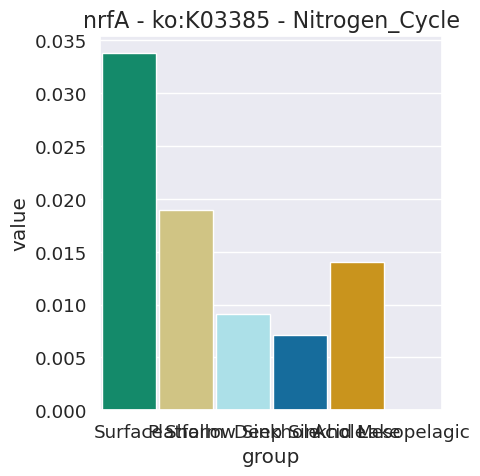

Saved: ../output//nrfA_ko_K03385_Nitrogen_Cycle.png

amoA (ko:K10944) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



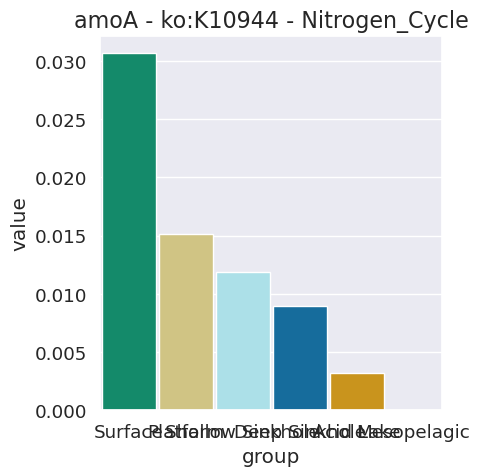

Saved: ../output//amoA_ko_K10944_Nitrogen_Cycle.png

nosZ (ko:K00376) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



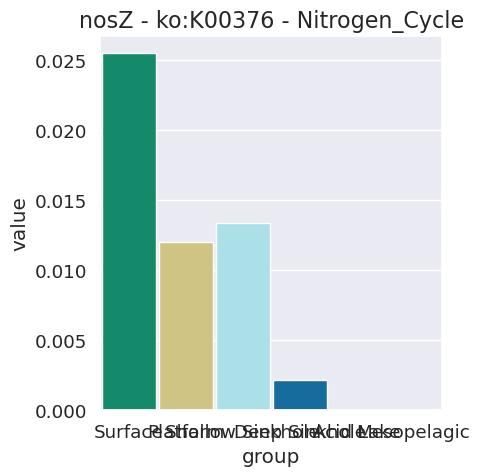

Saved: ../output//nosZ_ko_K00376_Nitrogen_Cycle.png

nxrA (ko:K00370) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



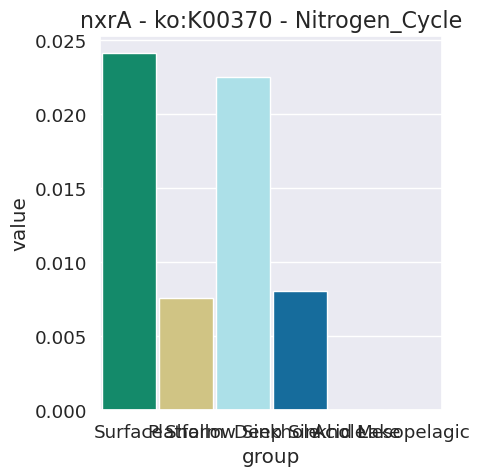

Saved: ../output//nxrA_ko_K00370_Nitrogen_Cycle.png

norB (ko:K04561) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a', 'Mesopelagic': 'b'}



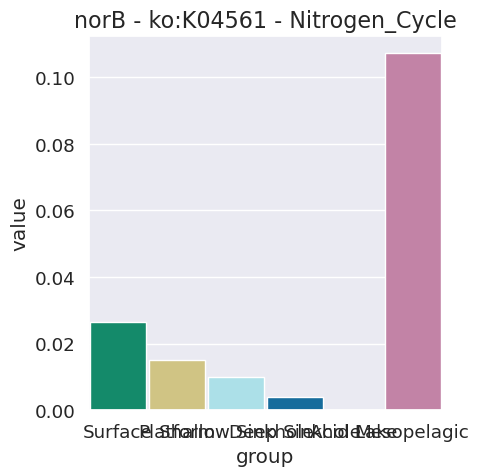

Saved: ../output//norB_ko_K04561_Nitrogen_Cycle.png

nirS (ko:K15864) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



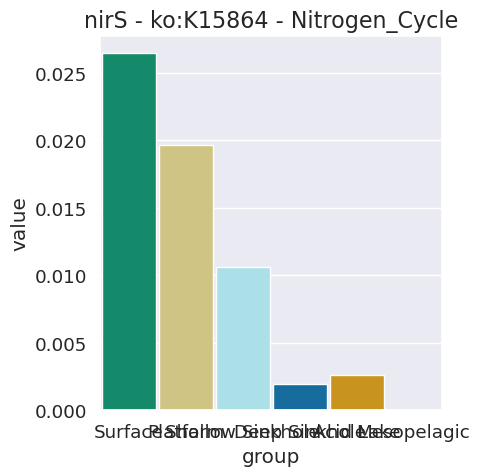

Saved: ../output//nirS_ko_K15864_Nitrogen_Cycle.png

hao (ko:K10535) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



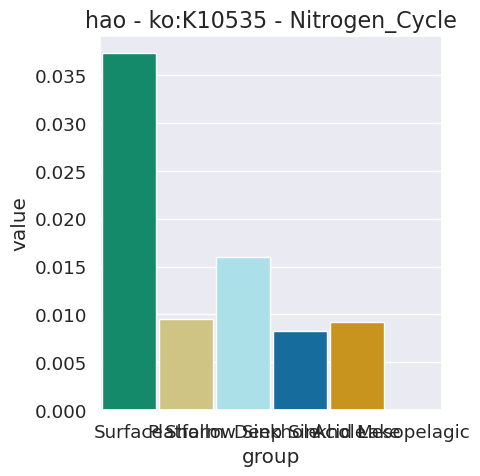

Saved: ../output//hao_ko_K10535_Nitrogen_Cycle.png

nifH (ko:K02588) Tukey HSD groupings:
{'Shallow Sinkhole': 'a', 'Mesopelagic': 'a', 'Deep Sinkhole': 'a', 'Platform': 'a', 'Surface': 'a', 'Acid Lake': 'a'}



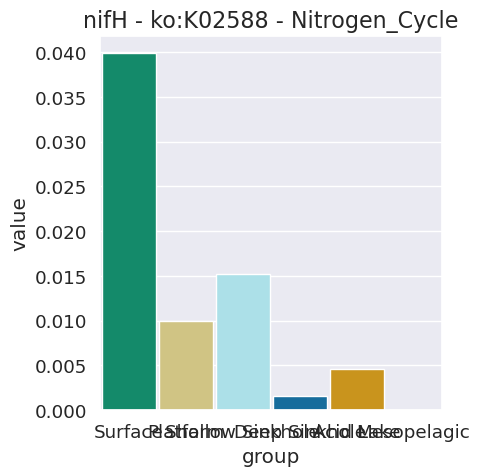

Saved: ../output//nifH_ko_K02588_Nitrogen_Cycle.png


In [133]:
# Reshape abundance data to long format for selected KOs
plot_data = (
    data.T[selected_kos]
    .reset_index()
    .melt(id_vars='index', var_name='ko', value_name='value')
    .rename(columns={'index': 'SampleID'})
)

# Map sample groups onto samples
plot_data['group'] = plot_data['SampleID'].map(
    abiotic['Cluster'].to_dict()
)

# Drop rows without a group assignment
plot_data = plot_data.dropna(subset=['group'])


for gene_name, ko_id in SELECTED_GENES.items():
    gene_data = plot_data[plot_data['ko'] == ko_id]

    if gene_data.empty:
        print(f"Warning: no data found for {gene_name} ({ko_id}), skipping.")
        continue

    plot_gene_abundance(gene_data, gene_name, ko_id, GROUP_COLORS, VALUE_SCALE, FIGSIZE, PATHS['output_dir'], kegg_map=KEGG_MAP)
